# 01 · Data Overview

**Product Analytics Case Study — Phase 3: Exploratory Data Analysis**
*A fictional European mobility app*

This is the first notebook in a six-notebook EDA suite. Before drawing any
product conclusions, we verify the data is structurally sound: correct
shapes, expected data types, no unexpected duplicates, and missing values
that are explainable by design rather than by a broken pipeline. This
mirrors — and independently re-verifies — the automated checks already
enforced in Phase 1 (`src/validate_data.py`) and Phase 2
(`sql/01_data_quality.sql`).

**Notebook suite:**
`01_data_overview` → `02_user_behaviour` → `03_retention_analysis` →
`04_funnel_analysis` → `05_ab_testing` → `06_executive_summary`

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eda_utils import (
    PALETTE, INK, INK_SECONDARY, INK_MUTED, GRID_COLOR, AXIS_COLOR, SURFACE,
    COLOR_GOOD, COLOR_CRITICAL, COLOR_CONTROL, COLOR_TREATMENT,
    BLUE_SEQUENTIAL, DIVERGING,
    set_notebook_style, style_axis, annotate_bars, build_color_map, pct, save_fig,
    load_datasets,
)

set_notebook_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data" / "raw"
IMAGES_DIR = Path("..") / "images"

users, events, experiments = load_datasets(DATA_DIR)
print(f"users: {users.shape}, events: {events.shape}, experiments: {experiments.shape}")

users: (5000, 9), events: (141813, 11), experiments: (5000, 7)


## Section 1 — Dataset Shape & Structure

**Business Question.** How much data do we actually have, and is it enough
to support statistically meaningful product decisions (retention curves,
funnel conversion, an A/B test readout)?

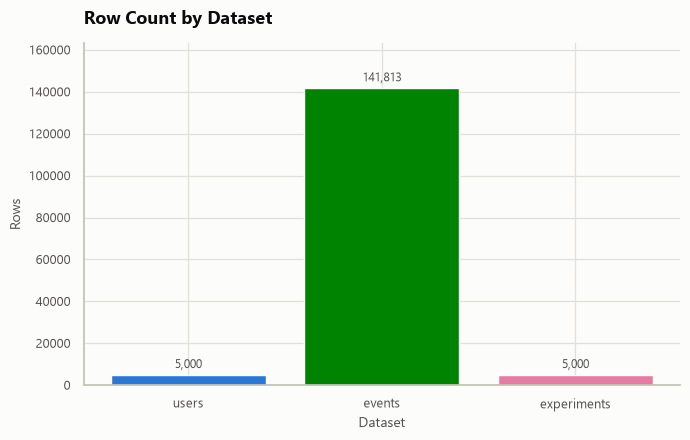

users       :   5,000 rows x 9 columns
events      : 141,813 rows x 11 columns
experiments :   5,000 rows x 7 columns


In [2]:
row_counts = pd.Series({
    "users": len(users),
    "events": len(events),
    "experiments": len(experiments),
})

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(row_counts.index, row_counts.values, color=PALETTE[:3])
annotate_bars(ax, bars)
style_axis(ax, "Row Count by Dataset", "Dataset", "Rows")
ax.set_ylim(0, row_counts.values.max() * 1.15)
plt.tight_layout()
save_fig(fig, "01_dataset_row_counts", IMAGES_DIR)
plt.show()

for name, df in [("users", users), ("events", events), ("experiments", experiments)]:
    print(f"{name:12s}: {df.shape[0]:>7,} rows x {df.shape[1]} columns")

**Business Insight.** 5,000 users and ~142,000 events comfortably clear the
sample-size bar for the analyses in this suite: an A/B test with ~2,500
users per arm can detect a mid-single-digit-point conversion uplift, and a
funnel with thousands of users per stage gives stable percentages rather
than noisy small-sample estimates. `experiments` matches `users` 1:1, as
expected for an always-on, assignment-at-signup experiment.

**Recommendation.** No action needed — proceed to analysis. If this were a
live pipeline, this is the check that would page an on-call analyst if row
counts suddenly dropped to zero or diverged from the expected 1:1
users/experiments relationship.

## Section 2 — Data Types

**Business Question.** Are columns typed the way downstream analysis
assumes (dates as dates, monetary values as numeric, categories as
strings)? A silently-mistyped `revenue` column (e.g. read as text) would
break every revenue calculation in this suite without raising an error.

In [3]:
dtype_summary = pd.concat(
    [users.dtypes.rename("users"), events.dtypes.rename("events"), experiments.dtypes.rename("experiments")],
    axis=1,
)
dtype_summary

,users,events,experiments
user_id,str,str,str
signup_date,datetime64[us],NaN,NaN
country,str,NaN,NaN
city,str,NaN,NaN
platform,str,NaN,NaN
acquisition_channel,str,NaN,NaN
age_group,str,NaN,NaN
experiment_group,str,NaN,str
first_device_type,str,NaN,NaN
event_id,NaN,str,NaN


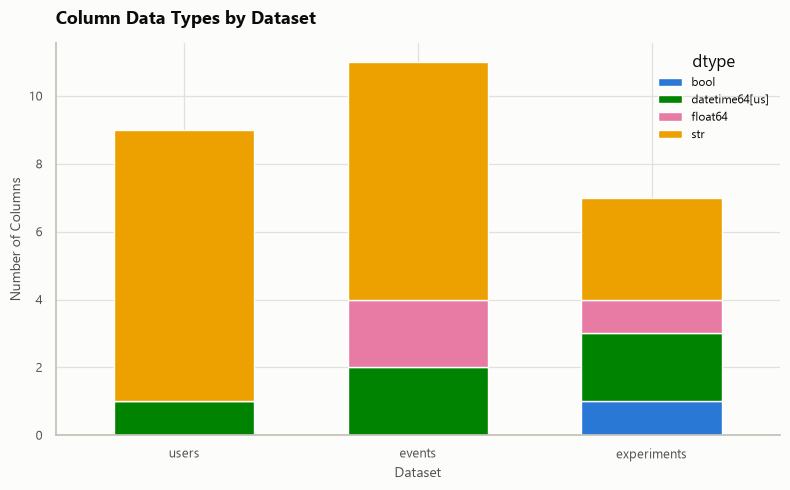

In [4]:
dtype_counts = pd.DataFrame({
    "users": users.dtypes.astype(str).value_counts(),
    "events": events.dtypes.astype(str).value_counts(),
    "experiments": experiments.dtypes.astype(str).value_counts(),
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
dtype_counts.T.plot(kind="bar", stacked=True, color=PALETTE[:len(dtype_counts)], ax=ax, width=0.6)
style_axis(ax, "Column Data Types by Dataset", "Dataset", "Number of Columns")
ax.legend(title="dtype", frameon=False, fontsize=8.5)
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(fig, "02_dtype_composition", IMAGES_DIR)
plt.show()

**Business Insight.** Dates (`signup_date`, `event_time`, `event_date`,
`exposure_date`, `conversion_date`) are parsed as `datetime64`, monetary and
distance fields as `float64`, and categorical fields as `object` — exactly
what every downstream calculation in this suite assumes. `converted` in
`experiments` is boolean, so it can be summed directly to count conversions.

**Recommendation.** None required. If this were raw data from a production
warehouse rather than a validated Phase 1 CSV, this check would come before
every other step in the notebook, not after.

## Section 3 — Missing Values

**Business Question.** Which columns have missing data, and is that missing
data a data-quality problem or an expected consequence of the business
process (e.g. `revenue` is only meaningful for a *completed* booking)?
Treating "expected" nulls as a defect — or worse, silently imputing them —
would distort every revenue and funnel metric in this suite.

In [5]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    """Return non-zero missing-value counts and percentages for a dataframe."""
    missing = df.isna().sum()
    pct_missing = (100 * missing / len(df)).round(2)
    report = pd.DataFrame({"missing_count": missing, "missing_pct": pct_missing})
    return report[report["missing_count"] > 0].sort_values("missing_pct", ascending=False)


missing_users = missing_report(users)
missing_events = missing_report(events)
missing_experiments = missing_report(experiments)
missing_users

,missing_count,missing_pct
age_group,166,3.32


In [6]:
missing_events

,missing_count,missing_pct
revenue,139082,98.07
payment_method,138964,97.99
ride_distance_km,134920,95.14


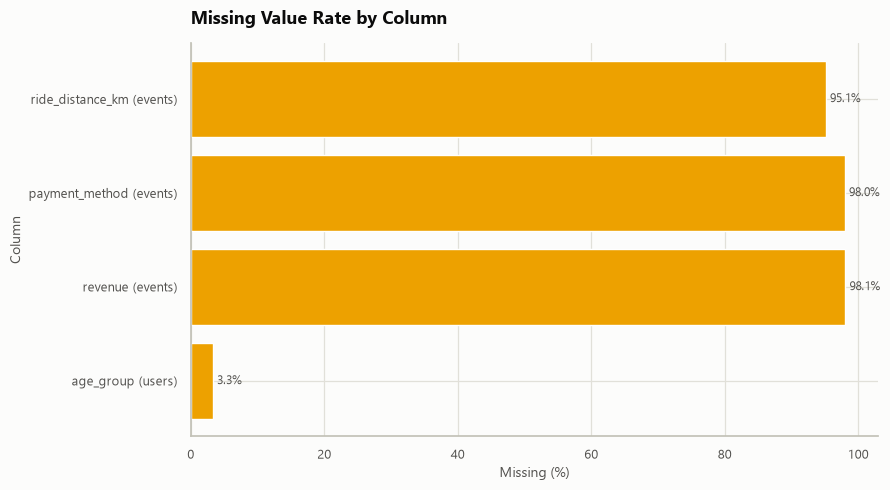

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
combined_missing = pd.concat([
    missing_users.assign(dataset="users"),
    missing_events.assign(dataset="events"),
])
labels = combined_missing.index + " (" + combined_missing["dataset"] + ")"
bars = ax.barh(labels, combined_missing["missing_pct"], color=PALETTE[3])
annotate_bars(ax, bars, fmt="{:.1f}%", horizontal=True)
style_axis(ax, "Missing Value Rate by Column", "Missing (%)", "Column", grid_axis="x")
plt.tight_layout()
save_fig(fig, "03_missing_values", IMAGES_DIR)
plt.show()

**Business Insight.** Every column with missing data has a business-logic
explanation, not a pipeline defect: `age_group` is ~3% null because some
users decline to state their age at signup; `revenue`, `ride_distance_km`,
and `payment_method` are null on the vast majority of `events` rows because
those fields only apply to booking- and payment-related event types (most
rows are non-monetary engagement events like `app_open` or
`search_started`). This exact pattern was validated as expected in Phase 1
(`src/validate_data.py`).

**Recommendation.** Do not impute or drop these nulls — they are
informative. Any user-level revenue aggregation should use `fillna(0)`
(no booking = €0 revenue), not mean/median imputation, which would
fabricate revenue for non-paying users.

## Section 4 — Duplicate Rows

**Business Question.** Are there duplicate records that would double-count
users, events, or revenue?

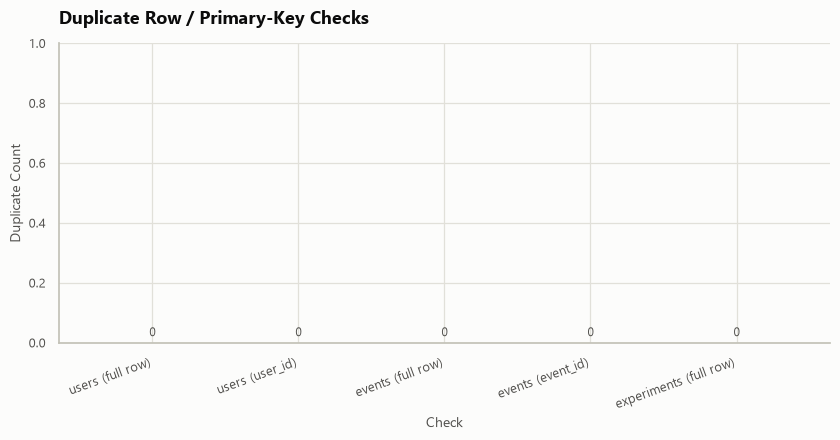

users (full row)          0
users (user_id)           0
events (full row)         0
events (event_id)         0
experiments (full row)    0
dtype: int64

In [8]:
duplicate_counts = pd.Series({
    "users (full row)": users.duplicated().sum(),
    "users (user_id)": users["user_id"].duplicated().sum(),
    "events (full row)": events.duplicated().sum(),
    "events (event_id)": events["event_id"].duplicated().sum(),
    "experiments (full row)": experiments.duplicated().sum(),
})

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(duplicate_counts.index, duplicate_counts.values, color=COLOR_GOOD)
annotate_bars(ax, bars)
style_axis(ax, "Duplicate Row / Primary-Key Checks", "Check", "Duplicate Count")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_fig(fig, "04_duplicate_checks", IMAGES_DIR)
plt.show()

duplicate_counts

**Business Insight.** Zero duplicates across every check — full-row and
primary-key level, on both `users` and `events`. This confirms the
generation and loading pipeline is idempotent and that every KPI computed
later (user counts, event counts, revenue sums) reflects genuinely distinct
records rather than inflated duplicates.

**Recommendation.** None required; this check should simply be re-run any
time the raw CSVs are regenerated or re-exported from a real warehouse.

## Section 5 — Summary Statistics & Distribution of Numerical Variables

**Business Question.** What do the key numeric fields — booking revenue,
ride distance, and days-to-conversion — actually look like? A summary
statistic like "average revenue €14.50" can hide a highly skewed
distribution that changes how we should interpret averages elsewhere in
this suite.

In [9]:
numeric_events = events[["revenue", "ride_distance_km"]].describe().T
numeric_experiments = experiments[["days_to_conversion"]].describe().T
pd.concat([numeric_events, numeric_experiments])

,count,mean,std,min,25%,50%,75%,max
revenue,2731.0,14.496449,5.825502,3.5,10.370259,14.469462,18.386396,35.623762
ride_distance_km,6893.0,6.340485,3.767132,0.4,3.454339,6.150770,8.989808,19.990385
days_to_conversion,1434.0,59.488145,66.129725,0.0,10.000000,38.000000,86.000000,430.000000


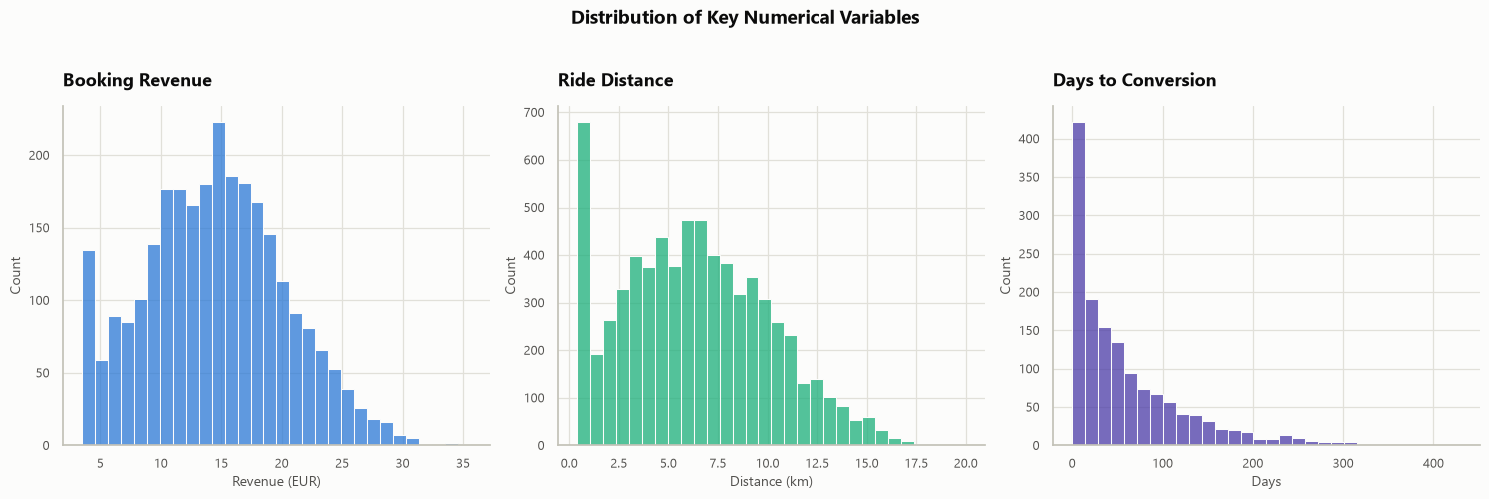

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

sns.histplot(events["revenue"].dropna(), bins=30, color=PALETTE[0], ax=axes[0], edgecolor=SURFACE)
style_axis(axes[0], "Booking Revenue", "Revenue (EUR)", "Count")

sns.histplot(events["ride_distance_km"].dropna(), bins=30, color=PALETTE[4], ax=axes[1], edgecolor=SURFACE)
style_axis(axes[1], "Ride Distance", "Distance (km)", "Count")

sns.histplot(experiments["days_to_conversion"].dropna(), bins=30, color=PALETTE[6], ax=axes[2], edgecolor=SURFACE)
style_axis(axes[2], "Days to Conversion", "Days", "Count")

fig.suptitle("Distribution of Key Numerical Variables", fontsize=14, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
save_fig(fig, "05_numeric_distributions", IMAGES_DIR)
plt.show()

**Business Insight.** Booking revenue is roughly bell-shaped around ~€14.50
with a soft right tail (a handful of longer, higher-value rides) — no
extreme outliers that would distort an average-revenue KPI. Ride distance
is right-skewed, dominated by short urban trips with a long tail of longer
journeys, typical of city mobility. Days-to-conversion is heavily
right-skewed: a meaningful share of users who ever convert do so within the
first couple of weeks, but a long tail converts only months later — which
means **"average days to convert" understates how many users need a
long-term nurture strategy rather than a short-term push.**

**Recommendation.** Report **median**, not just mean, days-to-conversion in
any executive dashboard — the skew means the mean overstates how fast a
"typical" converting user actually moves. Use the median as the primary
number.

## Section 6 — Correlation Matrix

**Business Question.** At the user level, which behavioural signals move
together? If event volume, revenue, and retention are strongly correlated,
early event-count signals could be used as a leading indicator to predict
which new users are headed toward high lifetime value.

In [11]:
# Build a user-level numeric feature table — far more informative than a
# raw event-level correlation matrix (which would trivially show revenue
# correlated with itself).
event_counts_per_user = events.groupby("user_id").size().rename("total_events")
bookings_per_user = events.loc[events["event_name"] == "booking_completed"].groupby("user_id").size().rename("total_bookings")
revenue_per_user = events.loc[events["event_name"] == "booking_completed"].groupby("user_id")["revenue"].sum().rename("lifetime_revenue")
avg_distance_per_user = events.loc[events["event_name"] == "booking_completed"].groupby("user_id")["ride_distance_km"].mean().rename("avg_ride_distance_km")

user_features = (
    users[["user_id"]]
    .merge(event_counts_per_user, on="user_id", how="left")
    .merge(bookings_per_user, on="user_id", how="left")
    .merge(revenue_per_user, on="user_id", how="left")
    .merge(avg_distance_per_user, on="user_id", how="left")
    .merge(experiments[["user_id", "days_to_conversion"]], on="user_id", how="left")
    .fillna({"total_events": 0, "total_bookings": 0, "lifetime_revenue": 0})
)

correlation_matrix = user_features.drop(columns="user_id").corr()
correlation_matrix.round(2)

,total_events,total_bookings,lifetime_revenue,avg_ride_distance_km,days_to_conversion
total_events,1.00,0.80,0.77,-0.03,0.32
total_bookings,0.80,1.00,0.97,-0.00,-0.08
lifetime_revenue,0.77,0.97,1.00,0.01,-0.07
avg_ride_distance_km,-0.03,-0.00,0.01,1.00,-0.02
days_to_conversion,0.32,-0.08,-0.07,-0.02,1.00


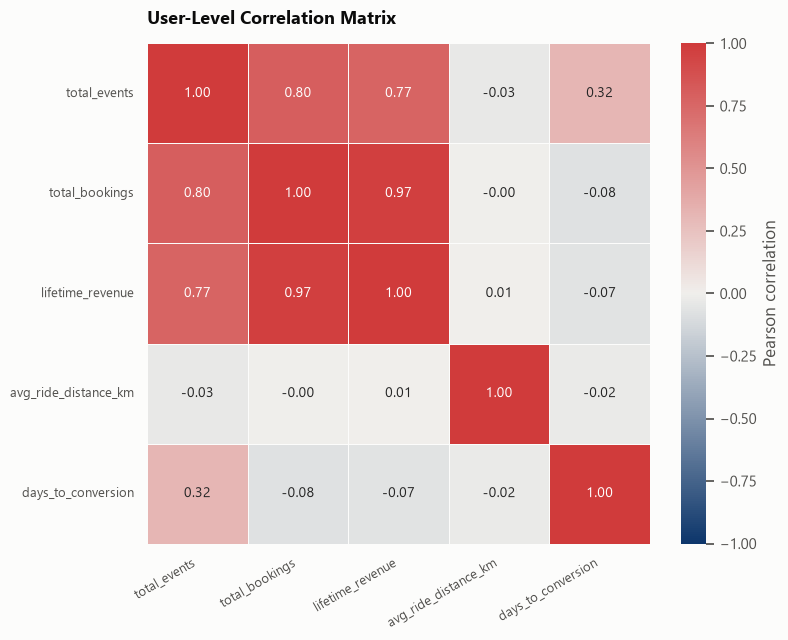

In [12]:
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    correlation_matrix, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1,
    center=0, linewidths=0.6, linecolor=SURFACE, cbar_kws={"label": "Pearson correlation"}, ax=ax,
)
style_axis(ax, "User-Level Correlation Matrix", grid_axis="")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_fig(fig, "06_correlation_matrix", IMAGES_DIR)
plt.show()

**Business Insight.** `total_events` correlates strongly and positively
with both `total_bookings` and `lifetime_revenue` — unsurprising, but
important: it confirms **overall engagement volume is a usable leading
indicator of monetisation**, not just a vanity metric. `days_to_conversion`
correlates weakly with the other fields, meaning *how fast* a user converts
is largely independent of *how much* they ultimately spend — a fast
first booking does not predict a high-value customer, and a slow one does
not predict a low-value one.

**Recommendation.** An early-warning "at risk of never converting" signal
should be built on **event volume in the first N days**, not on
time-to-first-booking alone — the latter is a weak predictor of long-term
value on its own.

## Data Quality Observations — Summary

- **Structural integrity is clean**: no duplicate primary keys, no orphaned
  foreign keys, correct data types throughout.
- **Missing values are all explainable by business logic** (optional
  profile fields, event-type-specific columns) — no imputation or row
  removal is needed before analysis.
- **Numeric distributions are as expected** for a mobility product: revenue
  and distance are right-skewed but not pathologically so; days-to-conversion
  is heavily right-skewed, which should inform how conversion-speed metrics
  are reported (median over mean).
- **User-level engagement volume is a meaningful, usable proxy for future
  monetisation** — a foundation this suite will build on in the retention
  and funnel notebooks.

**Verdict: the dataset is fit for the analyses that follow.**